# Multimodal Rag pipeline

# System Dependencies

"""brew install poppler tesseract libmagic"""

To get started with Unstructured.io, we need a few system-wide dependencies: 

## Poppler (poppler-utils)
Handles PDF processing. It's a library that can extract text, images, and metadata from PDFs. Unstructured uses it to parse PDF documents and convert them into processable text.

## Tesseract (tesseract-ocr) 
Optical Character Recognition (OCR) engine. When you have scanned documents, images with text, or PDFs that are essentially pictures, Tesseract reads the text from these images and converts it to machine-readable text.

## libmagic
File type detection library. It identifies what type of file you're dealing with (PDF, Word doc, image, etc.) by analyzing the file's content, not just the extension. This helps Unstructured choose the right processing method for each document.

In [10]:
%pip install -Uq "unstructured[all-docs]" 
%pip install -Uq langchain_chroma 
%pip install -Uq langchain langchain-community langchain-openai langchain-groq langchain-huggingface huggingface_hub
%pip install -Uq python_dotenv
%pip install -Uq typing

FileNotFoundError: [WinError 2] The system cannot find the file specified

In [12]:
import json
from typing import List 
# unstructured document parsing
from unstructured.partition.pdf import partition_pdf
from unstructured.chunking.title import chunk_by_title
# langchain components
from langchain_core.documents import Document 
from langchain_huggingface import HuggingFaceEndpointEmbeddings,ChatHuggingFace
from langchain_chroma import Chroma
from langchain_core.messages import SystemMessage, HumanMessage,AIMessage
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv
load_dotenv()

False

## 1. Paritioning the pdf into atomic elements using unstrucutred library

the unstructured library invokes a document-layout detection model (Detectron2/YOLOX depending on version) and then processes every page individually.

In [13]:
def partition_document(file_path: str):
    """Extract elements from PDF using unstructured"""
    print(f"Partitioning document: {file_path}")
    
    elements = partition_pdf(
        filename=file_path,  # Path to your PDF file
        strategy="hi_res", # Use the most accurate (but slower) processing method of extraction
        infer_table_structure=True, # Keep tables as structured HTML, not jumbled text
        extract_image_block_types=["Image"], # Grab images found in the PDF
        extract_image_block_to_payload=True # Store images as base64 data you can actually use
    )
    
    print(f"Extracted {len(elements)} elements")
    return elements

# Test with your PDF file
file_path = "../data/SDR0503.pdf"  # Change this to your PDF path
elements = partition_document(file_path)

Partitioning document: ../data/SDR0503.pdf


Cannot set non-stroke color because expected 3 components but got [1]
No languages specified, defaulting to English.


Extracted 56 elements


In [14]:
len(elements)

56

In [4]:
elements

## All types of extracted elemets

In [15]:
set([str(type(el)) for el in elements])

{"<class 'unstructured.documents.elements.FigureCaption'>",
 "<class 'unstructured.documents.elements.Image'>",
 "<class 'unstructured.documents.elements.ListItem'>",
 "<class 'unstructured.documents.elements.NarrativeText'>",
 "<class 'unstructured.documents.elements.Table'>",
 "<class 'unstructured.documents.elements.Text'>",
 "<class 'unstructured.documents.elements.Title'>"}

In [16]:
%pip install -Uq fitz
%pip install -Uq frontend

FileNotFoundError: [WinError 2] The system cannot find the file specified

In [20]:
!pip uninstall fitz PyMuPDF frontend -y
!pip install PyMuPDF

FileNotFoundError: [WinError 2] The system cannot find the file specified

In [9]:
import fitz  # PyMuPDF
from PIL import Image, ImageDraw
import io

def visualize_elements(pdf_path, elements, page_num=1, zoom=2, out_path=f"annotated{file_path}.png"):
    doc = fitz.open(pdf_path)
    page = doc[page_num - 1]

    # Render page at higher res for clarity
    mat = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=mat)
    img = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    draw = ImageDraw.Draw(img)

    # Actual rendered image size
    img_w, img_h = img.size

    for el in elements:
        meta = el["metadata"]
        if meta.get("page_number") != page_num:
            continue

        coords = meta["coordinates"]
        layout_w = coords["layout_width"]
        layout_h = coords["layout_height"]
        pts = coords["points"]

        # Scale from layout space -> rendered image space
        scale_x = img_w / layout_w
        scale_y = img_h / layout_h

        xs = [p[0] * scale_x for p in pts]
        ys = [p[1] * scale_y for p in pts]
        box = [min(xs), min(ys), max(xs), max(ys)]

        color = "red" if el["type"] == "ListItem" else "blue"
        draw.rectangle(box, outline=color, width=2)
        draw.text((box[0], max(0, box[1] - 12)), el["type"], fill=color)

    img.save(out_path)
    print(f"Saved to {out_path}")

ModuleNotFoundError: No module named 'fitz'

In [ ]:
def visualize_all_pages(pdf_path, elements, zoom=2, out_path="../data/AN699annotated.pdf"):
    doc = fitz.open(pdf_path)
    num_pages = len(doc)
    page_images = []

    for page_num in range(1, num_pages + 1):
        page = doc[page_num - 1]
        mat = fitz.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=mat)
        img = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
        draw = ImageDraw.Draw(img)

        img_w, img_h = img.size

        for el in elements:
            meta = el["metadata"]
            if meta.get("page_number") != page_num:
                continue

            coords = meta.get("coordinates")
            if coords is None:
                continue

            layout_w = coords["layout_width"]
            layout_h = coords["layout_height"]
            pts = coords["points"]

            scale_x = img_w / layout_w
            scale_y = img_h / layout_h

            xs = [p[0] * scale_x for p in pts]
            ys = [p[1] * scale_y for p in pts]
            box = [min(xs), min(ys), max(xs), max(ys)]

            color = "red" if el["type"] == "ListItem" else "blue"
            draw.rectangle(box, outline=color, width=2)
            draw.text((box[0], max(0, box[1] - 12)), el["type"], fill=color)

        page_images.append(img)
        print(f"Processed page {page_num}/{num_pages}")

    # Save all pages as a single multi-page PDF
    page_images[0].save(
        out_path,
        save_all=True,
        append_images=page_images[1:]
    )
    print(f"Saved {num_pages}-page annotated PDF to {out_path}")

In [ ]:
elements_dict = [el.to_dict() for el in elements]

In [ ]:
visualize_all_pages("../data/SDR0503.pdf", elements_dict, out_path="../data/SDR0503annotated.pdf")

In [ ]:
elements[1].to_dict()

In [ ]:
def filter_noise_elements(elements, noise_keywords=None):
    """Drop Image elements whose extracted text matches known logo/header noise."""
    if noise_keywords is None:
        noise_keywords = ["texas instruments"]

    cleaned = []
    removed = 0
    for el in elements:
        if type(el).__name__ == "Image":
            text_lower = (el.text or "").strip().lower()
            if any(kw in text_lower for kw in noise_keywords):
                removed += 1
                continue
        cleaned.append(el)

    print(f"Filtered out {removed} noise image(s)")
    return cleaned

# usage
elements = filter_noise_elements(elements)

In [ ]:
elements[0].to_dict()

In [ ]:
# Gather all images
images = [element for element in elements if element.category == 'Image']
print(f"Found {len(images)} images")

images[4].to_dict()

# Use https://codebeautify.org/base64-to-image-converter to view the base64 text

In [ ]:
# Gather all table
tables = [element for element in elements if element.category == 'Table']
print(f"Found {len(tables)} tables")

tables[3].to_dict()

# Use https://jsfiddle.net/ to view the table html 

In [ ]:
def create_chunks_by_title(elements):
    """Create intelligent chunks using title-based strategy"""
    print("Creating smart chunks...")
    
    chunks = chunk_by_title(
        elements, # The parsed PDF elements from previous step
        max_characters=3000, # Hard limit - never exceed 3000 characters per chunk
        new_after_n_chars=2100, # Try to start a new chunk after 2400 characters
        combine_text_under_n_chars=500, # Merge tiny chunks under 500 chars with neighbors
        isolate_table=False
    )
    
    print(f"Created {len(chunks)} chunks")
    return chunks

# Create chunks
chunks = create_chunks_by_title(elements)

In [ ]:
set([str(type(chunk)) for chunk in chunks])

# Inspecting our chunk 
## For this heading

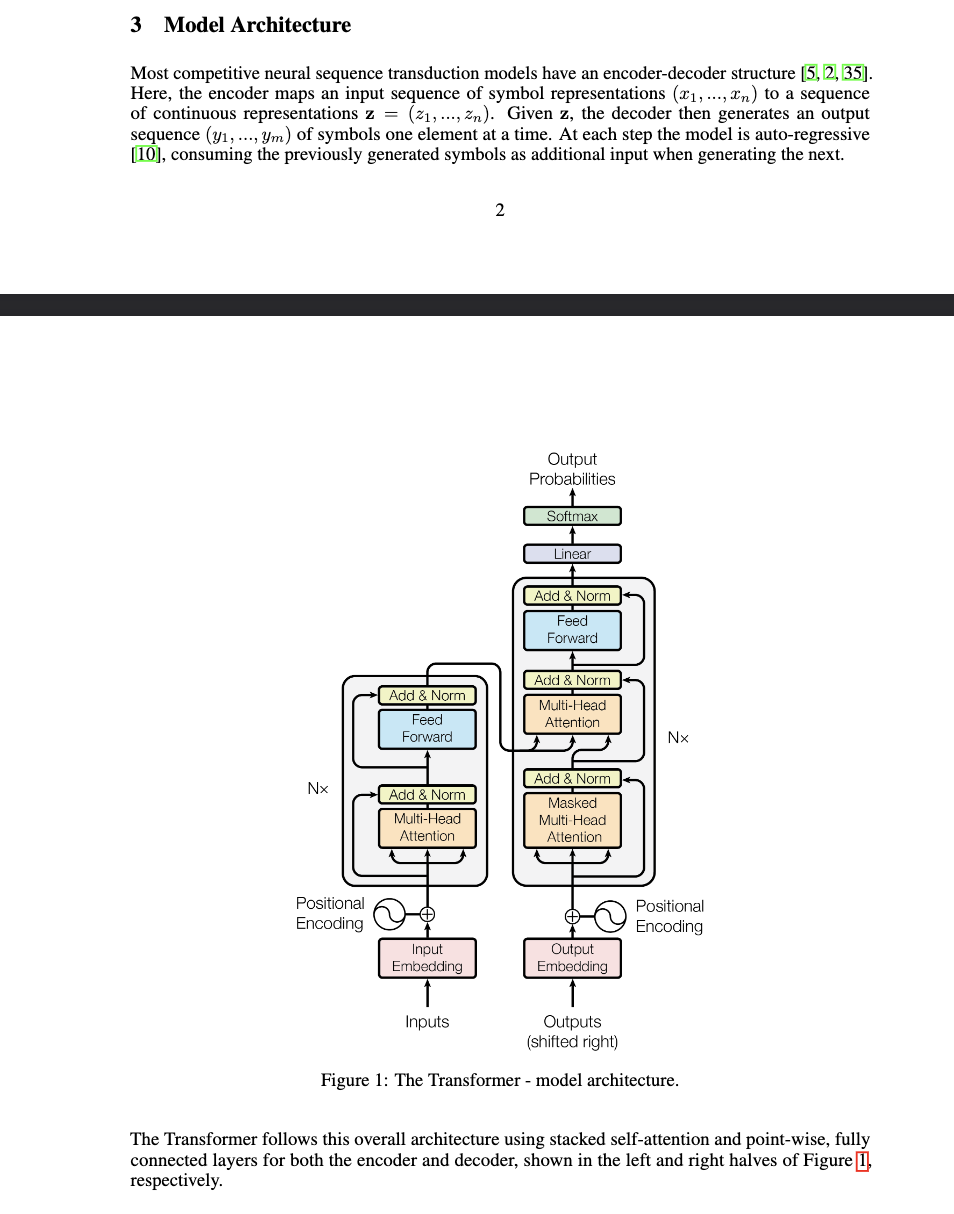

In [ ]:
# View a single chunk
chunks[4].to_dict()

In [ ]:
chunks[4].metadata.orig_elements

In [ ]:
# View original elements
chunks[4].metadata.orig_elements[0].to_dict()

In [ ]:
chunks[4].metadata.orig_elements[1].to_dict()

In [ ]:
chunks[4].metadata.orig_elements[3].to_dict()

In [ ]:
chunks[4].metadata.orig_elements[4].to_dict()

In [ ]:
chunks[4].metadata.orig_elements[5].to_dict()

In [ ]:
def separate_content_types(chunk):
    """Analyze what types of content are in a chunk"""
    content_data = {
        'text': chunk.text,
        'tables': [],
        'images': [],
        'types': ['text']
    }
    
    # Check for tables and images in original elements
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for element in chunk.metadata.orig_elements:
            element_type = type(element).__name__
            
            # Handle tables
            if element_type == 'Table':
                content_data['types'].append('table')
                table_html = getattr(element.metadata, 'text_as_html', element.text)
                content_data['tables'].append(table_html)
            
            # Handle images
            elif element_type == 'Image':
                if hasattr(element, 'metadata') and hasattr(element.metadata, 'image_base64'):
                    content_data['types'].append('image')
                    content_data['images'].append(element.metadata.image_base64)
    
    content_data['types'] = list(set(content_data['types']))
    return content_data

In [ ]:
from langchain_openai import ChatOpenAI 
from langchain_huggingface import ChatHuggingFace
import os
llm = ChatOpenAI(
    model="Qwen/Qwen3-VL-235B-A22B-Thinking",
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
    temperature=0,
    max_tokens=1024,
)

In [ ]:
def create_ai_enhanced_summary(text: str, tables: List[str], images: List[str]) -> str:
    """Create AI-enhanced summary for mixed content"""
    
    try:
        # Initialize LLM (needs vision model for images)
        
        # Build the text prompt
        prompt_text = f"""You are creating a searchable description for document content retrieval.

        CONTENT TO ANALYZE:
        TEXT CONTENT:
        {text}

        {
            "cell_type": "code",
            "id": "#VSC-9e212c2d",
            "metadata": {
                "language": "python"
            },
            "source": [
                "import sys",
                "!{sys.executable} -m pip install -Uq PyMuPDF frontend"
            ]
        },

                1. Key facts, numbers, and data points from text and tables
                2. Main topics and concepts discussed  
                3. Questions this content could answer
                4. Visual content analysis (charts, diagrams, patterns in images)
                5. Alternative search terms users might use

                Make it detailed and searchable - prioritize findability over brevity.

                SEARCHABLE DESCRIPTION:"""

        # Build message content starting with text
        message_content = [{"type": "text", "text": prompt_text}]
        
        # Add images to the message
        for image_base64 in images:
            message_content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
            })
        
        # Send to AI and get response
        message = HumanMessage(content=message_content)
        response = llm.invoke([message])
        
        return response.content
        
    except Exception as e:
        print(f"     ❌ AI summary failed: {e}")
        # Fallback to simple summary
        summary = f"{text[:300]}..."
        if tables:
            summary += f" [Contains {len(tables)} table(s)]"
        if images:
            summary += f" [Contains {len(images)} image(s)]"
        return summary



In [ ]:
def summarise_chunks(chunks):
    """Process all chunks with AI Summaries"""
    print("🧠 Processing chunks with AI Summaries...")
    
    langchain_documents = []
    total_chunks = len(chunks)
    
    for i, chunk in enumerate(chunks):
        current_chunk = i + 1
        print(f"   Processing chunk {current_chunk}/{total_chunks}")
        
        # Analyze chunk content
        content_data = separate_content_types(chunk)
        
        # Debug prints
        print(f"     Types found: {content_data['types']}")
        print(f"     Tables: {len(content_data['tables'])}, Images: {len(content_data['images'])}")
        
        # Create AI-enhanced summary if chunk has tables/images
        if content_data['tables'] or content_data['images']:
            print(f"     → Creating AI summary for mixed content...")
            try:
                enhanced_content = create_ai_enhanced_summary(
                    content_data['text'],
                    content_data['tables'], 
                    content_data['images']
                )
                print(f"     → AI summary created successfully")
                print(f"     → Enhanced content preview: {enhanced_content[:200]}...")
            except Exception as e:
                print(f"     ❌ AI summary failed: {e}")
                enhanced_content = content_data['text']
        else:
            print(f"     → Using raw text (no tables/images)")
            enhanced_content = content_data['text']
        
        # Create LangChain Document with rich metadata
        doc = Document(
            page_content=enhanced_content,
            metadata={
                "original_content": json.dumps({
                    "raw_text": content_data['text'],
                    "tables_html": content_data['tables'],
                    "images_base64": content_data['images']
                })
            }
        )
        
        langchain_documents.append(doc)
    
    print(f"Processed {len(langchain_documents)} chunks")
    return langchain_documents


# Process chunks with AI
processed_chunks = summarise_chunks(chunks)


In [ ]:
from langchain_openai import ChatOpenAI
hf_multi_image_llm = ChatOpenAI(
    model="zai-org/GLM-4.5V",
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
    temperature=0,
    max_tokens=1024,
)

In [ ]:
processed_chunks

In [ ]:
def export_chunks_to_json(chunks, filename="chunks_export.json"):
    """Export processed chunks to clean JSON format"""
    export_data = []
    
    for i, doc in enumerate(chunks):
        chunk_data = {
            "chunk_id": i + 1,
            "enhanced_content": doc.page_content,
            "metadata": {
                "original_content": json.loads(doc.metadata.get("original_content", "{}"))
            }
        }
        export_data.append(chunk_data)
    
    # Save to file
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Exported {len(export_data)} chunks to {filename}")
    return export_data

# Export your chunks
json_data = export_chunks_to_json(processed_chunks,filename="../json/SDR0503chunks.json")

In [ ]:
from langchain_huggingface import HuggingFaceEndpointEmbeddings
def create_vector_store(documents, persist_directory="dbv1/chroma_db"):
    """Create and persist ChromaDB vector store"""
    print("🔮 Creating embeddings and storing in ChromaDB...")
        
    embedding_model= HuggingFaceEndpointEmbeddings(model="ibm-granite/granite-embedding-97m-multilingual-r2")
    
    # Create ChromaDB vector store
    print("--- Creating vector store ---")
    vectorstore = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        persist_directory=persist_directory, 
        collection_metadata={"hnsw:space": "cosine"}
    )
    print("--- Finished creating vector store ---")
    
    print(f"✅ Vector store created and saved to {persist_directory}")
    return vectorstore

# Create the vector store
db = create_vector_store(processed_chunks)

In [ ]:
# After your retrieval
query = "explain the internal architecture"
retriever = db.as_retriever(search_kwargs={"k": 5})
chunks = retriever.invoke(query)

# Export to JSON
export_chunks_to_json(chunks, "rag_results.json")

In [ ]:
def run_complete_ingestion_pipeline(pdf_path: str):
    """Run the complete RAG ingestion pipeline"""
    print("🚀 Starting RAG Ingestion Pipeline")
    print("=" * 50)
    
    # Step 1: Partition
    elements = partition_document(pdf_path)
    
    # Step 2: Chunk
    chunks = create_chunks_by_title(elements)
    
    # Step 3: AI Summarisation
    summarised_chunks = summarise_chunks(chunks)
    
    # Step 4: Vector Store
    db = create_vector_store(summarised_chunks, persist_directory="dbv2/chroma_db")
    
    print("Pipeline completed successfully!")
    return db

In [ ]:
# Query the vector store
import os
from langchain_huggingface import (
    ChatHuggingFace,
    HuggingFaceEndpoint
)


query = "How many attention heads does the Transformer use, and what is the dimension of each head? "

retriever = db.as_retriever(search_kwargs={"k": 3})
chunks = retriever.invoke(query)

def generate_final_answer(chunks, query):
    """Generate final answer using multimodal content"""
    
    try:
        # Initialize LLM (needs vision model for images)
        hf_llm = HuggingFaceEndpoint(
            repo_id="zai-org/GLM-4.5V",
            huggingfacehub_api_token=os.getenv("HF_TOKEN"),
            task="text-generation",
            max_new_tokens=1024,
            temperature=0,
        )

        llm = ChatHuggingFace(
            llm=hf_llm
        )
        # Build the text prompt
        prompt_text = f"""Based on the following documents, please answer this question: {query}

CONTENT TO ANALYZE:
"""
        
        for i, chunk in enumerate(chunks):
            prompt_text += f"--- Document {i+1} ---\n"
            
            if "original_content" in chunk.metadata:
                original_data = json.loads(chunk.metadata["original_content"])
                
                # Add raw text
                raw_text = original_data.get("raw_text", "")
                if raw_text:
                    prompt_text += f"TEXT:\n{raw_text}\n\n"
                
                # Add tables as HTML
                tables_html = original_data.get("tables_html", [])
                if tables_html:
                    prompt_text += "TABLES:\n"
                    for j, table in enumerate(tables_html):
                        prompt_text += f"Table {j+1}:\n{table}\n\n"
            
            prompt_text += "\n"
        
        prompt_text += """
Please provide a clear, comprehensive answer using the text, tables, and images above. If the documents don't contain sufficient information to answer the question, say "I don't have enough information to answer that question based on the provided documents."

ANSWER:"""

        # Build message content starting with text
        message_content = [{"type": "text", "text": prompt_text}]
        
        # Add all images from all chunks
        for chunk in chunks:
            if "original_content" in chunk.metadata:
                original_data = json.loads(chunk.metadata["original_content"])
                images_base64 = original_data.get("images_base64", [])
                
                for image_base64 in images_base64:
                    message_content.append({
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
                    })
        
        # Send to AI and get response
        message = HumanMessage(content=message_content)
        response = llm.invoke([message])
        
        return response.content
        
    except Exception as e:
        print(f"Answer generation failed: {e}")
        return "Sorry, I encountered an error while generating the answer."

# Usage
final_answer = generate_final_answer(chunks, query)
print(final_answer)

In [ ]:
import shutil
import os

persist_directory = "../dbv2/chroma_db"

if os.path.exists(persist_directory):
    shutil.rmtree(persist_directory)
    print(f"Deleted existing vector store: {persist_directory}")
else:
    print("Vector store does not exist.")

In [ ]:
import shutil
shutil.rmtree("../dbv1/chroma_db", ignore_errors=True)

In [ ]:
import json
import base64
import time
from pathlib import Path

from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEndpointEmbeddings


def ingest_json_directory(
    json_directory: str = '../json',
    persist_directory: str = "../dbv2/chroma_db",
    images_directory: str = "../dbv2/images",
):
    """
    Reads all JSON files from a directory and ingests them into ChromaDB.
    Images are saved as separate files to avoid bloating ChromaDB metadata.
    """

    print("=" * 50)
    print("INGESTION PIPELINE START")
    print("=" * 50)

    print("\n[1/4] Loading embedding model...")
    embedding_model = HuggingFaceEndpointEmbeddings(
        model="ibm-granite/granite-embedding-97m-multilingual-r2",
    )
    print(f"  Model: {embedding_model.model}")

    print("\n[2/4] Preparing documents and images...")
    images_dir = Path(images_directory)
    images_dir.mkdir(parents=True, exist_ok=True)

    documents = []

    json_files = sorted(Path(json_directory).glob("*.json"))

    if not json_files:
        raise FileNotFoundError(f"No JSON files found in {json_directory}")

    print(f"  Found {len(json_files)} JSON files")

    total_images = 0
    total_tables = 0
    total_raw_chars = 0

    for json_file in json_files:
        print(f"\n  Processing: {json_file.name}")

        with open(json_file, "r", encoding="utf-8") as f:
            chunks = json.load(f)

        print(f"    Chunks in file: {len(chunks)}")

        for chunk in chunks:

            original = chunk["metadata"]["original_content"]
            source_stem = json_file.stem
            chunk_id = chunk["chunk_id"]

            images_b64 = original.get("images_base64", [])
            tables = original.get("tables_html", [])
            raw_text = original.get("raw_text", "")

            image_paths = []
            for idx, b64 in enumerate(images_b64):
                img_filename = f"{source_stem}_c{chunk_id}_img{idx}.jpg"
                img_path = images_dir / img_filename
                img_path.write_bytes(base64.b64decode(b64))
                image_paths.append(str(img_path))

            total_images += len(images_b64)
            total_tables += len(tables)
            total_raw_chars += len(raw_text)

            metadata = {
                "source": json_file.stem,
                "chunk_id": chunk_id,
                "raw_text": raw_text,
                "tables_html": json.dumps(tables, ensure_ascii=False),
                "image_paths": json.dumps(image_paths, ensure_ascii=False),
                "has_table": len(tables) > 0,
                "has_image": len(images_b64) > 0,
            }

            documents.append(
                Document(
                    page_content=chunk["enhanced_content"],
                    metadata=metadata,
                )
            )

    print(f"\n  Document summary:")
    print(f"    Total chunks: {len(documents)}")
    print(f"    Total images saved: {total_images}")
    print(f"    Total tables: {total_tables}")
    print(f"    Total raw text chars: {total_raw_chars:,}")

    print(f"\n[3/4] Generating embeddings ({len(documents)} chunks)...")
    print("  This may take a while depending on API quota...")

    t0 = time.time()
    try:
        db = Chroma.from_documents(
            documents=documents,
            embedding=embedding_model,
            persist_directory=persist_directory,
            collection_metadata={"hnsw:space": "cosine"},
        )
        elapsed = time.time() - t0
        print(f"  Embeddings completed in {elapsed:.1f}s")
        print(f"  Collection size: {db._collection.count()} documents")

    except Exception as e:
        elapsed = time.time() - t0
        print(f"\n  ERROR after {elapsed:.1f}s: {type(e).__name__}: {e}")

        if "429" in str(e) or "rate" in str(e).lower() or "quota" in str(e).lower():
            print("\n  -> QUOTA/RATE LIMIT EXCEEDED")
            print("  -> Wait a few minutes and re-run this cell.")
            print("  -> Or switch to a local embedding model (e.g. sentence-transformers).")
        elif "401" in str(e) or "403" in str(e) or "auth" in str(e).lower():
            print("\n  -> AUTH ERROR - check your HF_TOKEN")
        elif "readonly" in str(e).lower():
            print("\n  -> DATABASE LOCKED - delete the persist_directory and re-run.")
        else:
            print(f"\n  -> Unexpected error, check the traceback above.")

        raise

    print(f"\n[4/4] Verifying...")
    count = db._collection.count()
    print(f"  Documents in ChromaDB: {count}")
    if count != len(documents):
        print(f"  WARNING: Expected {len(documents)} but got {count}")

    print(f"\n  Images saved to: {images_dir.resolve()}")
    print(f"  DB saved to: {Path(persist_directory).resolve()}")

    print("\n" + "=" * 50)
    print("INGESTION COMPLETE")
    print("=" * 50)

    return db

ingest_json_directory()


In [ ]:
import json

with open("../json/lm317chunks.json") as f:
    chunks = json.load(f)

for chunk in chunks:
    imgs = chunk["metadata"]["original_content"].get("images_base64", [])
    if imgs:
        print(chunk["chunk_id"], len(imgs))

In [21]:
import fitz

print("PyMuPDF Installed")
print(fitz.__doc__)


ModuleNotFoundError: No module named 'fitz'